In [1]:
%reload_ext autoreload
%autoreload 2

from autocvd import autocvd
autocvd(num_gpus=1)

import jax
import jax.numpy as jnp

import time as tt

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})

import StreaMAX

In [2]:
from gala import potential

pot = potential.potential.MilkyWayPotential2022()

for k in pot.keys():
    print(k, pot[k], pot[k].parameters)

disk MN3ExponentialDiskPotential {'m': <Quantity 4.7717e+10 solMass>, 'h_R': <Quantity 2.6 kpc>, 'h_z': <Quantity 0.3 kpc>}
bulge HernquistPotential {'m': <Quantity 5.e+09 solMass>, 'c': <Quantity 1. kpc>}
nucleus HernquistPotential {'m': <Quantity 1.8142e+09 solMass>, 'c': <Quantity 0.0688867 kpc>}
halo NFWPotential {'m': <Quantity 5.5427e+11 solMass>, 'r_s': <Quantity 15.626 kpc>, 'a': <Quantity 1.>, 'b': <Quantity 1.>, 'c': <Quantity 1.>}


## First, start by defining the parameters

In [17]:
from math import log10
# Flattened NFW halo
type_host   = 'MW2022'
params_halo = {'logM': log10(5.5427e+11), 'Rs': 15.626, 'a':1, 'b': 1.0, 'c': 1.0,
               'dirx': 0.0, 'diry': 0.0, 'dirz': 1.0,
                'x_origin': 0.0, 'y_origin': 0.0, 'z_origin': 0.0}
params_disk = {'logM': log10(4.7717e+10), 
               'Rs': 2.6, 'Hs': 0.3, 
                'positive_density': True, 'sech2_z':True,
                'dirx': 0.0, 'diry': 0.0, 'dirz': 1.0,
                'x_origin': 0.0, 'y_origin': 0.0, 'z_origin': 0.0}
params_bulge = {'logM': log10(5.e09), 'Rs': 1.,
             'dirx': 0.0, 'diry': 0.0, 'dirz': 1.0,
             'x_origin': 0.0, 'y_origin': 0.0, 'z_origin': 0.0}
params_nucleus = {'logM': log10(1.8142e+09), 'Rs': 0.0688867,
             'dirx': 0.0, 'diry': 0.0, 'dirz': 1.0,
             'x_origin': 0.0, 'y_origin': 0.0, 'z_origin': 0.0}
params_host = {'halo_params': params_halo, 
            'disk_params': params_disk, 
            'bulge_params': params_bulge, 
            'nucleus_params': params_nucleus}

# Plummer Sattelite
type_sat   = 'Plummer'
params_sat = {'logM': 4.0, 'Rs': 1.0,
                'x_origin': 0.0, 'y_origin': 0.0, 'z_origin': 0.0}

# Initial conditions
xv_f = jnp.array([10.0, 0.0, 0.0,  # Position in kpc
                0.0, 200.0, 0.0])   # Velocity in kpc/Gyr

# Integration time
time  = 1.5 # Gyr
alpha = 1.

n_particles = 10000
n_steps     = 199 # n_steps+1 must be a factor of n_particles
unroll      = False

## Testing against gala MW2022

In [18]:
import numpy as np
import astropy.units as u
from gala import potential

pot = potential.potential.MilkyWayPotential2022()

# Test point
x, y, z = 10.0, 5.0, 3.0
q = np.array([[x], [y], [z]]) * u.kpc

params_disk_jax = {k: (jnp.bool_(v) if isinstance(v, bool) else v) for k, v in params_disk.items()}

print("="*70)
print(f"Comparison at (x, y, z) = ({x}, {y}, {z}) kpc")
print("="*70)

# ---------- Disk (MN3ExponentialDisk) ----------
phi_disk_gala = pot['disk'].energy(q).to(u.kpc**2 / u.Gyr**2).value[0]
phi_disk_smax = StreaMAX.potentials.MN3ExpDisk_potential(x, y, z, params_disk_jax)

acc_disk_gala = pot['disk'].acceleration(q).to(u.kpc / u.Gyr**2).value.flatten()
acc_disk_smax = StreaMAX.potentials.MN3ExpDisk_acceleration(x, y, z, params_disk_jax)

print("\n--- Disk (MN3ExpDisk) ---")
print(f"  Potential  Gala: {phi_disk_gala:.6f}    StreaMAX: {float(phi_disk_smax):.6f}    diff: {abs(phi_disk_gala - float(phi_disk_smax)):.2e}")
print(f"  Accel x    Gala: {acc_disk_gala[0]:.6f}    StreaMAX: {float(acc_disk_smax[0]):.6f}    diff: {abs(acc_disk_gala[0] - float(acc_disk_smax[0])):.2e}")
print(f"  Accel y    Gala: {acc_disk_gala[1]:.6f}    StreaMAX: {float(acc_disk_smax[1]):.6f}    diff: {abs(acc_disk_gala[1] - float(acc_disk_smax[1])):.2e}")
print(f"  Accel z    Gala: {acc_disk_gala[2]:.6f}    StreaMAX: {float(acc_disk_smax[2]):.6f}    diff: {abs(acc_disk_gala[2] - float(acc_disk_smax[2])):.2e}")

# ---------- Bulge (Hernquist) ----------
phi_bulge_gala = pot['bulge'].energy(q).to(u.kpc**2 / u.Gyr**2).value[0]
phi_bulge_smax = StreaMAX.potentials.Hernquist_potential(x, y, z, params_bulge)

acc_bulge_gala = pot['bulge'].acceleration(q).to(u.kpc / u.Gyr**2).value.flatten()
acc_bulge_smax = StreaMAX.potentials.Hernquist_acceleration(x, y, z, params_bulge)

print("\n--- Bulge (Hernquist) ---")
print(f"  Potential  Gala: {phi_bulge_gala:.6f}    StreaMAX: {float(phi_bulge_smax):.6f}    diff: {abs(phi_bulge_gala - float(phi_bulge_smax)):.2e}")
print(f"  Accel x    Gala: {acc_bulge_gala[0]:.6f}    StreaMAX: {float(acc_bulge_smax[0]):.6f}    diff: {abs(acc_bulge_gala[0] - float(acc_bulge_smax[0])):.2e}")
print(f"  Accel y    Gala: {acc_bulge_gala[1]:.6f}    StreaMAX: {float(acc_bulge_smax[1]):.6f}    diff: {abs(acc_bulge_gala[1] - float(acc_bulge_smax[1])):.2e}")
print(f"  Accel z    Gala: {acc_bulge_gala[2]:.6f}    StreaMAX: {float(acc_bulge_smax[2]):.6f}    diff: {abs(acc_bulge_gala[2] - float(acc_bulge_smax[2])):.2e}")

# ---------- Nucleus (Hernquist) ----------
phi_nuc_gala = pot['nucleus'].energy(q).to(u.kpc**2 / u.Gyr**2).value[0]
phi_nuc_smax = StreaMAX.potentials.Hernquist_potential(x, y, z, params_nucleus)

acc_nuc_gala = pot['nucleus'].acceleration(q).to(u.kpc / u.Gyr**2).value.flatten()
acc_nuc_smax = StreaMAX.potentials.Hernquist_acceleration(x, y, z, params_nucleus)

print("\n--- Nucleus (Hernquist) ---")
print(f"  Potential  Gala: {phi_nuc_gala:.6f}    StreaMAX: {float(phi_nuc_smax):.6f}    diff: {abs(phi_nuc_gala - float(phi_nuc_smax)):.2e}")
print(f"  Accel x    Gala: {acc_nuc_gala[0]:.6f}    StreaMAX: {float(acc_nuc_smax[0]):.6f}    diff: {abs(acc_nuc_gala[0] - float(acc_nuc_smax[0])):.2e}")
print(f"  Accel y    Gala: {acc_nuc_gala[1]:.6f}    StreaMAX: {float(acc_nuc_smax[1]):.6f}    diff: {abs(acc_nuc_gala[1] - float(acc_nuc_smax[1])):.2e}")
print(f"  Accel z    Gala: {acc_nuc_gala[2]:.6f}    StreaMAX: {float(acc_nuc_smax[2]):.6f}    diff: {abs(acc_nuc_gala[2] - float(acc_nuc_smax[2])):.2e}")

# ---------- Halo (NFW) ----------
# NOTE: Gala's MW2022 uses spherical NFW (a=b=c=1), your params have b=0.5, c=0.5
# Use spherical params for fair comparison
params_halo_spherical = {**params_halo, 'a': 1.0, 'b': 1.0, 'c': 1.0}

phi_halo_gala = pot['halo'].energy(q).to(u.kpc**2 / u.Gyr**2).value[0]
phi_halo_smax = StreaMAX.potentials.NFW_potential(x, y, z, params_halo_spherical)

acc_halo_gala = pot['halo'].acceleration(q).to(u.kpc / u.Gyr**2).value.flatten()
acc_halo_smax = StreaMAX.potentials.NFW_acceleration(x, y, z, params_halo_spherical)

print("\n--- Halo (NFW) ---")
print(f"  Potential  Gala: {phi_halo_gala:.6f}    StreaMAX: {float(phi_halo_smax):.6f}    diff: {abs(phi_halo_gala - float(phi_halo_smax)):.2e}")
print(f"  Accel x    Gala: {acc_halo_gala[0]:.6f}    StreaMAX: {float(acc_halo_smax[0]):.6f}    diff: {abs(acc_halo_gala[0] - float(acc_halo_smax[0])):.2e}")
print(f"  Accel y    Gala: {acc_halo_gala[1]:.6f}    StreaMAX: {float(acc_halo_smax[1]):.6f}    diff: {abs(acc_halo_gala[1] - float(acc_halo_smax[1])):.2e}")
print(f"  Accel z    Gala: {acc_halo_gala[2]:.6f}    StreaMAX: {float(acc_halo_smax[2]):.6f}    diff: {abs(acc_halo_gala[2] - float(acc_halo_smax[2])):.2e}")

# ---------- Total ----------
phi_tot_gala = pot.energy(q).to(u.kpc**2 / u.Gyr**2).value[0]
# Use spherical halo for fair total comparison
params_host_spherical = {**params_host, 'halo_params': params_halo_spherical}
phi_tot_smax = StreaMAX.potentials.MW2022_potential(x, y, z, params_host_spherical)

acc_tot_gala = pot.acceleration(q).to(u.kpc / u.Gyr**2).value.flatten()
acc_tot_smax = StreaMAX.potentials.MW2022_acceleration(x, y, z, params_host_spherical)

print("\n--- Total (MW2022) ---")
print(f"  Potential  Gala: {phi_tot_gala:.6f}    StreaMAX: {float(phi_tot_smax):.6f}    diff: {abs(phi_tot_gala - float(phi_tot_smax)):.2e}")
print(f"  Accel x    Gala: {acc_tot_gala[0]:.6f}    StreaMAX: {float(acc_tot_smax[0]):.6f}    diff: {abs(acc_tot_gala[0] - float(acc_tot_smax[0])):.2e}")
print(f"  Accel y    Gala: {acc_tot_gala[1]:.6f}    StreaMAX: {float(acc_tot_smax[1]):.6f}    diff: {abs(acc_tot_gala[1] - float(acc_tot_smax[1])):.2e}")
print(f"  Accel z    Gala: {acc_tot_gala[2]:.6f}    StreaMAX: {float(acc_tot_smax[2]):.6f}    diff: {abs(acc_tot_gala[2] - float(acc_tot_smax[2])):.2e}")

# ---------- Relative errors ----------
print("\n" + "="*70)
print("Relative errors (|StreaMAX - Gala| / |Gala|)")
print("="*70)
print(f"  Disk potential:    {abs(phi_disk_gala - float(phi_disk_smax)) / abs(phi_disk_gala):.2e}")
print(f"  Bulge potential:   {abs(phi_bulge_gala - float(phi_bulge_smax)) / abs(phi_bulge_gala):.2e}")
print(f"  Nucleus potential: {abs(phi_nuc_gala - float(phi_nuc_smax)) / abs(phi_nuc_gala):.2e}")
print(f"  Halo potential:    {abs(phi_halo_gala - float(phi_halo_smax)) / abs(phi_halo_gala):.2e}")
print(f"  Total potential:   {abs(phi_tot_gala - float(phi_tot_smax)) / abs(phi_tot_gala):.2e}")
print(f"  Total accel norm:  {np.linalg.norm(acc_tot_gala - np.array(acc_tot_smax)) / np.linalg.norm(acc_tot_gala):.2e}")

Comparison at (x, y, z) = (10.0, 5.0, 3.0) kpc

--- Disk (MN3ExpDisk) ---
  Potential  Gala: -20421.799045    StreaMAX: -20421.867188    diff: 6.81e-02
  Accel x    Gala: -1364.848028    StreaMAX: -1364.850952    diff: 2.92e-03
  Accel y    Gala: -682.424014    StreaMAX: -682.425476    diff: 1.46e-03
  Accel z    Gala: -789.518437    StreaMAX: -789.521118    diff: 2.68e-03

--- Bulge (Hernquist) ---
  Potential  Gala: -1788.549814    StreaMAX: -1788.549194    diff: 6.20e-04
  Accel x    Gala: -122.860349    StreaMAX: -122.860329    diff: 2.04e-05
  Accel y    Gala: -61.430175    StreaMAX: -61.430164    diff: 1.02e-05
  Accel z    Gala: -36.858105    StreaMAX: -36.858097    diff: 7.66e-06

--- Nucleus (Hernquist) ---
  Potential  Gala: -700.848116    StreaMAX: -700.848083    diff: 3.29e-05
  Accel x    Gala: -51.992695    StreaMAX: -51.992699    diff: 3.99e-06
  Accel y    Gala: -25.996347    StreaMAX: -25.996349    diff: 2.00e-06
  Accel z    Gala: -15.597808    StreaMAX: -15.597809   

## Second, generate the stream!

In [ ]:
# Defines the way initial conditions for the particle spray are created
type_method    = 'Fardal2015'

# Defines the final mass of satellite for a fixed linear mass loss
m_f_sat = 0.0

In [26]:
a = tt.time()
t_sat, xv_sat, xv_stream, xhi_stream = jax.block_until_ready(StreaMAX.generate_stream(xv_f, 
                                                                type_host, params_host, 
                                                                type_sat, params_sat, 
                                                                time, alpha, n_steps,
                                                                n_particles, 
                                                                unroll, type_method=type_method,
                                                                m_f_sat=m_f_sat))
b = tt.time()
print("Time taken to compile the pipeline and generate the stream with unroll=False: {:.3f} s".format((b-a)))

a = tt.time()
t_sat, xv_sat, xv_stream, xhi_stream = jax.block_until_ready(StreaMAX.generate_stream(xv_f, 
                                                                type_host, params_host, 
                                                                type_sat, params_sat, 
                                                                time, alpha, n_steps,
                                                                n_particles, 
                                                                unroll, type_method=type_method,
                                                                m_f_sat=m_f_sat))
b = tt.time()
print("Time taken to generate the stream with unroll=False: {:.3f} ms".format((b-a)*1000))

Time taken to compile the pipeline and generate the stream with unroll=False: 0.052 s
Time taken to generate the stream with unroll=False: 51.625 ms


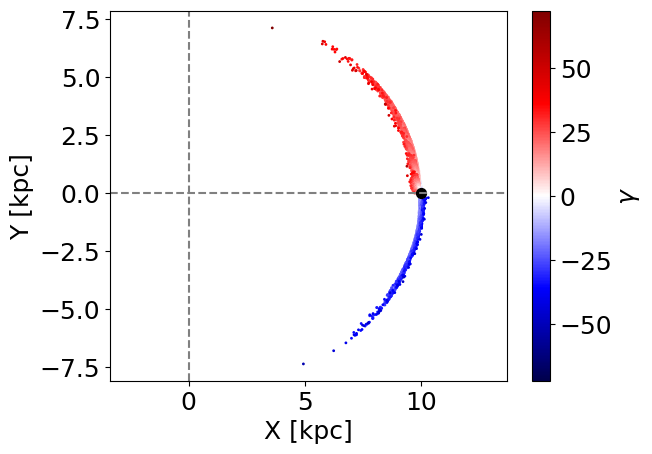

In [27]:
plt.scatter(xv_stream[:, 0], xv_stream[:, 1], c=xhi_stream, cmap='seismic', 
            vmin=min([min(xhi_stream), min(-xhi_stream)]), vmax=max([max(xhi_stream), max(-xhi_stream)]), s=1, alpha=1.)
plt.colorbar(label=r'$\gamma$')
plt.axvline(0, c='grey', linestyle='--')
plt.axhline(0, c='grey', linestyle='--')
plt.scatter(xv_sat[-1, 0], xv_sat[-1, 1], c='black', s=50)
plt.xlabel('X [kpc]')
plt.ylabel('Y [kpc]')
plt.axis('equal');

In [8]:
xv_stream.shape

(10000, 6)

### Get the Track

Usually when we work with stream, we are not interested in the complete stream but the radial position, width and density at given angle bins. We use the ordering to compute the angle bins and unwrap the stream. The angle is always centered on the final position of the satellite and follows an anti-clockwise ordering (contrairy to the ordering which is always positive for the leading tail and negative for the trailing).

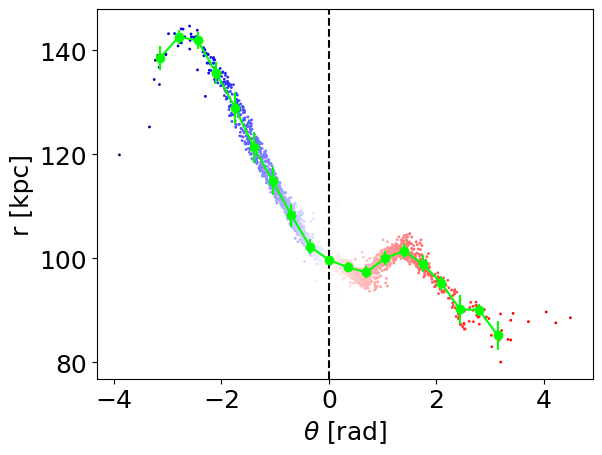

In [6]:
# Get ordered stream
x_stream, y_stream, theta_stream, r_stream, xhi_ordered = StreaMAX.get_stream_ordered(xv_stream[:, 0], xv_stream[:, 1], xhi_stream)

# Define widths and centers of the theta bins
widths       = jnp.deg2rad(20.)
theta_center = jnp.arange(-jnp.pi, jnp.pi, widths)

# Get 2D track vectorized
r_bin, sig_bin, count_bin = jax.vmap(StreaMAX.get_track_2D, in_axes=(None, None, 0, None))(theta_stream, r_stream, theta_center, widths)

plt.scatter(theta_stream, r_stream, c=xhi_ordered, cmap='seismic', 
            vmin=min([min(xhi_ordered), min(-xhi_ordered)]), vmax=max([max(xhi_ordered), max(-xhi_ordered)]), s=1, alpha=1.)
plt.errorbar(theta_center, r_bin, yerr=sig_bin, fmt='-o', c='lime')
plt.axvline(0, c='k', linestyle='--')
plt.xlabel(r'$\theta$ [rad]')
plt.ylabel('r [kpc]');

## Unroll

On a CPU, if you set unroll to be True, JAX will compile every iteration of the "for" loop. This makes the compiling a lot slower but the computation of the stream even faster. Therefore, we recommend setting unroll=True for longer jobs that will require generating multiple streams (i.e. optimization, bayesian inference). Note that this option is only viable if the n_steps is not too big since that parameter fixes how many iterations have to be compiled.

On a GPU, this is irrelevant.

In [7]:
unroll = True

a = tt.time()
t_sat, xv_sat, xv_stream, xhi_stream = jax.block_until_ready(StreaMAX.generate_stream(xv_f, 
                                                        type_host, params_host, 
                                                        type_sat, params_sat, 
                                                        time, alpha, n_steps,
                                                        n_particles, 
                                                        unroll))
b = tt.time()
print("Time taken to compile the pipeline and generate the stream with unroll=True: {:.3f} s".format((b-a)))

a = tt.time()
t_sat, xv_sat, xv_stream, xhi_stream = jax.block_until_ready(StreaMAX.generate_stream(xv_f, 
                                                                type_host, params_host, 
                                                                type_sat, params_sat, 
                                                                time, alpha, n_steps,
                                                                n_particles, 
                                                                unroll))
b = tt.time()
print("Time taken to generate the stream with unroll=True: {:.3f} ms".format((b-a)*1000))

Time taken to compile the pipeline and generate the stream with unroll=True: 15.234 s
Time taken to generate the stream with unroll=True: 25.198 ms


# Time Scaling

Let's see how computation time scales as a function of number of particles compared to $\texttt{Gala}$

In [8]:
import astropy.units as u
import numpy as np
import gala.potential as gp
import gala.dynamics as gd
import gala.integrate as gi
from gala.dynamics import mockstream as ms
from gala.units import galactic

pot = gp.NFWPotential(m=10**params_host['logM']*u.Msun, r_s=params_host['Rs']*u.kpc, units=galactic)
H = gp.Hamiltonian(pot)

prog_w0 = gd.PhaseSpacePosition(pos=[xv_f[0].item(), xv_f[1].item(), xv_f[2].item()] * u.kpc,
                                vel=[xv_f[3].item(), xv_f[4].item(), xv_f[5].item()] * u.kpc/u.Gyr)

df = ms.FardalStreamDF(gala_modified=True)
prog_mass =  10**params_sat['logM'] * u.Msun

gen = ms.MockStreamGenerator(df, H)

In [9]:
StreaMAX_time, Gala_time = [], []
n_particles_list = [1000, 5000, 10_000, 50_000, 100_000]
for n_particles in n_particles_list:
    # Compiling
    t_sat, xv_sat, xv_stream, xhi_stream = StreaMAX.generate_stream(xv_f, 
                                                            type_host, params_host, 
                                                            type_sat, params_sat, 
                                                            time, alpha, n_steps,
                                                            n_particles, 
                                                            unroll)

    StreaMAX_average, Gala_average = 0, 0
    for _ in range(100):
        a = tt.time()
        t_sat, xv_sat, xv_stream, xhi_stream = jax.block_until_ready(StreaMAX.generate_stream(xv_f, 
                                                                        type_host, params_host, 
                                                                        type_sat, params_sat, 
                                                                        time, alpha, n_steps,
                                                                        n_particles, 
                                                                        unroll))
        b = tt.time()
        StreaMAX_average += (b-a)*1000

        a = tt.time()
        stream, prog = gen.run(prog_w0, prog_mass, dt=-time/(n_steps) * u.Gyr, n_steps=n_steps, n_particles=n_particles/200, Integrator='leapfrog')
        b = tt.time()
        Gala_average += (b-a)*1000

    StreaMAX_time.append(StreaMAX_average/100)
    Gala_time.append(Gala_average/100)

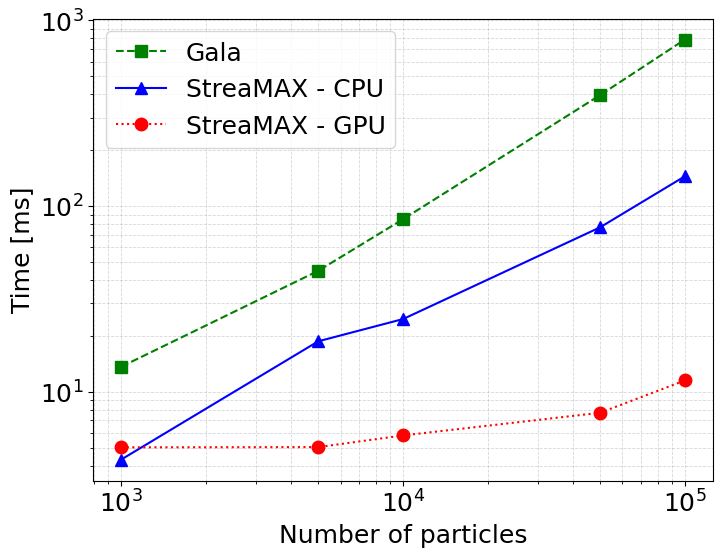

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(
    n_particles_list, Gala_time,
    linestyle='--', marker='s', linewidth=1.5, markersize=9,
    color='green', label='Gala'
)

plt.plot(
    n_particles_list, StreaMAX_time,
    marker='^', linewidth=1.5, markersize=9,
    color='blue', label='StreaMAX - CPU'
)

StreaMAX_time_GPU = [5.013, 5.031, 5.813, 7.700, 11.498] # Computed separately on a T4
plt.plot(
    n_particles_list, StreaMAX_time_GPU, marker='o',
    linestyle=':', linewidth=1.5, markersize=9,
    color='red', label='StreaMAX - GPU'
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of particles')
plt.ylabel('Time [ms]')
plt.legend(loc='best')
plt.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.5)